# **0: Problem Framing dan Penetapan Objektif**

Pemahaman mengenai alasan pembangunan model dari perspektif bisnis diperlukan dan sering kali merupakan langkah yang krusial.

**Konteks Bisnis (Domain Knowledge):** Di industri telekomunikasi, customer churn (pelanggan yang berhenti berlangganan) adalah tantangan. Biaya akuisisi pelanggan baru (Customer Acquisition Cost) jauh lebih mahal daripada biaya retensi pelanggan yang sudah ada (Customer Retention Cost).

**Masalah Bisnis:** Perusahaan mengalami kerugian pendapatan akibat pelanggan beralih ke kompetitor. Identifikasi pelanggan yang memerlukan fokus untuk dipertahankan masih belum jelas.

**Objektif Bisnis:** Pengurangan tingkat churn pelanggan melalui identifikasi proaktif pelanggan yang paling mungkin churn, memungkinkan perusahaan memberikan penawaran khusus (misalnya: diskon, upgrade layanan) untuk retensi.

**Objektif Machine Learning:** Pembangunan model klasifikasi biner yang mampu memprediksi probabilitas churn ('Yes') atau non-churn ('No') pelanggan berdasarkan data historis dan atribut layanan.

**Target Variabel (Label):** Kolom Churn.

**Jenis Masalah:** Supervised Learning, Binary Classification.

# **1: SETUP (LOAD LIBRARIES)**

Langkah pertama yaitu mengimport semua library python yang akan digunakan, meliputi library untuk manipulasi data (pandas, numpy), visualisasi (matplotlib, seaborn), preprocessing (sklearn.model_selection, sklearn.preprocessing), model (sklearn.linear_model, sklearn.ensemble, xgboost, sklearn.neural_network), dan evaluasi (sklearn.metrics).

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.neural_network import MLPClassifier

from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, accuracy_score, precision_score, recall_score, f1_score

sns.set(style='whitegrid')

# **2: Data Collection dan Understanding**

## 2.1: LOAD DATA & INSPEKSI AWAL
langkah ini memuat dataset. dataset yang digunakan adalah data [telco customer churn dari](https://www.kaggle.com/datasets/blastchar/telco-customer-churn/data) kaggle.setelah data dimuat. dilakukan inspeksi data dengan melihat beberapa baris pertama data, stuktur data, duplikat dan distribusi nilai data unik dari fitur kategorik untuk melihat dan memahami data.


In [ ]:
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

In [ ]:
pd.set_option('display.max_columns', None)
display(df.head())

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [ ]:
df.isna().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [ ]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

fitur TotalCharge bertipe object yang mungkin karena string. ini perlu dikonversi ke numerik terlebih dahulu karena fitur ini seharusnya numerik. parameter errors='cource' akan mengubah menjadi Nan jika tidak bisa dikonversi ke numerik

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [ ]:
duplicate_rows = df.duplicated().sum()
if duplicate_rows > 0:
    print(f"Jumlah data duplikat: {duplicate_rows}")
    print("-> Wawasan: Terdapat data duplikat yang perlu ditangani.")
else:
    print("Jumlah data duplikat: Tidak ada data duplikat.")

print("\nNilai Unik untuk Fitur Kategorikal:")
categorical_columns = df.select_dtypes(include=['object']).columns
for col in categorical_columns:
    print(f"- Kolom '{col}': {df[col].unique()}")

Jumlah data duplikat: Tidak ada data duplikat.

Nilai Unik untuk Fitur Kategorikal:
- Kolom 'customerID': ['7590-VHVEG' '5575-GNVDE' '3668-QPYBK' ... '4801-JZAZL' '8361-LTMKD'
 '3186-AJIEK']
- Kolom 'gender': ['Female' 'Male']
- Kolom 'Partner': ['Yes' 'No']
- Kolom 'Dependents': ['No' 'Yes']
- Kolom 'PhoneService': ['No' 'Yes']
- Kolom 'MultipleLines': ['No phone service' 'No' 'Yes']
- Kolom 'InternetService': ['DSL' 'Fiber optic' 'No']
- Kolom 'OnlineSecurity': ['No' 'Yes' 'No internet service']
- Kolom 'OnlineBackup': ['Yes' 'No' 'No internet service']
- Kolom 'DeviceProtection': ['No' 'Yes' 'No internet service']
- Kolom 'TechSupport': ['No' 'Yes' 'No internet service']
- Kolom 'StreamingTV': ['No' 'Yes' 'No internet service']
- Kolom 'StreamingMovies': ['No' 'Yes' 'No internet service']
- Kolom 'Contract': ['Month-to-month' 'One year' 'Two year']
- Kolom 'PaperlessBilling': ['Yes' 'No']
- Kolom 'PaymentMethod': ['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credi

tidak ada data yang mengalami kesalahan dalam fitur kategorik.Dan setelah konversi sebelumnya, fitur TotalCharge memiliki nilai missing.

## 2.3: Pengecekan Distribusi Fitur Kategorikal Penting (Value Counts)

Sel ini menampilkan *value counts* untuk beberapa fitur kategorikal yang dianggap penting berdasarkan analisis awal dan potensi relevansinya terhadap *churn*. Ini membantu kita memahami distribusi data di dalam setiap kategori fitur tersebut.

In [ ]:
important_categorical_features = [
    'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService',
    'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
    'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
    'Contract', 'PaperlessBilling', 'PaymentMethod'
]

print("\nValue Counts untuk Fitur Kategorikal Penting:")
for col in important_categorical_features:
    if col in df.columns and df[col].dtype == 'object':
        print(f"\n--- Kolom: '{col}' ---")
        display(df[col].value_counts())
        print("-" * (len(col) + 12))


Value Counts untuk Fitur Kategorikal Penting:

--- Kolom: 'gender' ---


,count
gender,
Male,3555
Female,3488


------------------

--- Kolom: 'Partner' ---


,count
Partner,
No,3641
Yes,3402


-------------------

--- Kolom: 'Dependents' ---


...

--------------------

--- Kolom: 'PaperlessBilling' ---


,count
PaperlessBilling,
Yes,4171
No,2872


----------------------------

--- Kolom: 'PaymentMethod' ---


,count
PaymentMethod,
Electronic check,2365
Mailed check,1612
Bank transfer (automatic),1544
Credit card (automatic),1522


-------------------------


# **3: Analisis Data Eksplorasi(EDA)**

Langkah ini fokus pada Analisis Data Eksplorasi (EDA). Kita menganalisis distribusi variabel target 'Churn', memeriksa statistik deskriptif dan visualisasi (boxplot) fitur numerik ('tenure', 'MonthlyCharges', 'TotalCharges') terhadap churn, serta memvisualisasikan hubungan antara fitur kategorikal kunci ('gender', 'Contract', 'InternetService', 'PaymentMethod') dengan churn menggunakan countplot. Heatmap korelasi fitur numerik juga ditampilkan.

### 3.1: Visualisasi Fitur Numerik vs. Churn (Box Plots)

Sel ini menampilkan box plot untuk fitur numerik ('tenure', 'MonthlyCharges', 'TotalCharges') dibandingkan dengan variabel target 'Churn'. Ini membantu mengidentifikasi bagaimana distribusi fitur numerik berbeda antara pelanggan yang churn dan tidak churn.

In [ ]:
numeric_features = df.select_dtypes(include=['int64', 'float64']).columns
print("Statistik Deskriptif Fitur Numerik:")
display(df[numeric_features].describe())

Statistik Deskriptif Fitur Numerik:


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7032.000000
mean,0.162147,32.371149,64.761692,2283.300441
std,0.368612,24.559481,30.090047,2266.771362
min,0.000000,0.000000,18.250000,18.800000
25%,0.000000,9.000000,35.500000,401.450000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.850000,3794.737500
max,1.000000,72.000000,118.750000,8684.800000


Distribusi Target 'Churn':


,proportion
Churn,
No,73.463013
Yes,26.536987


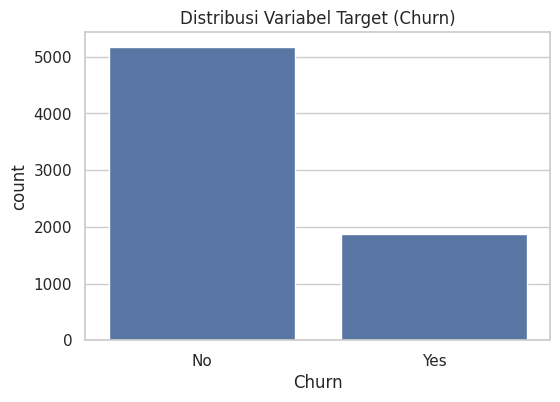

In [ ]:
print("Distribusi Target 'Churn':")
display(df['Churn'].value_counts(normalize=True) * 100)

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Churn')
plt.title('Distribusi Variabel Target (Churn)')
plt.show()

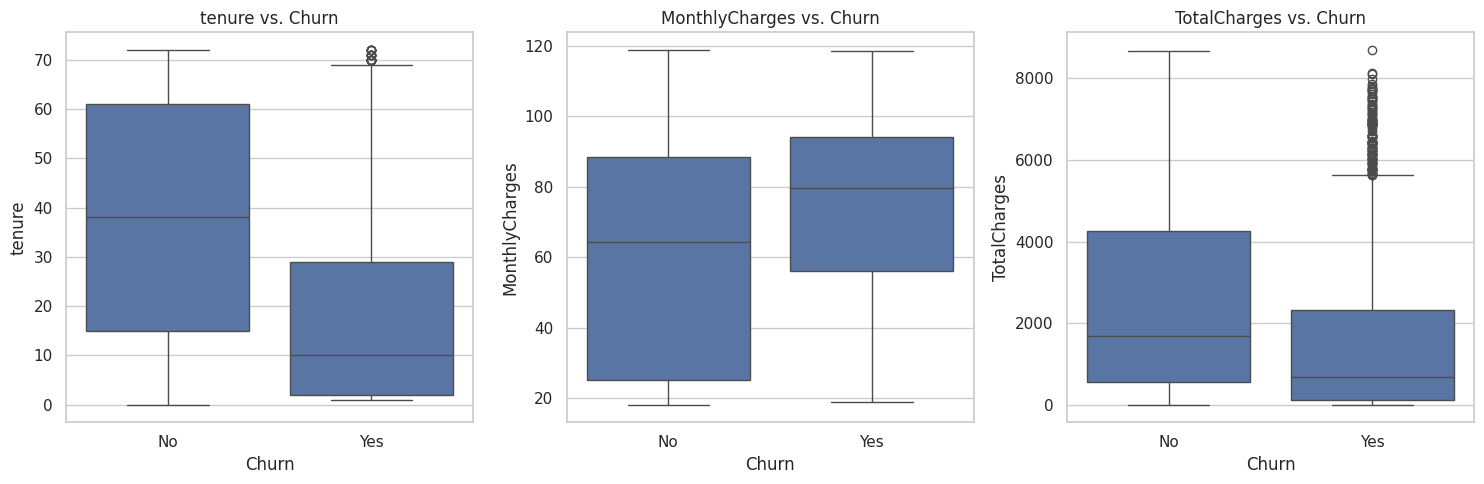

In [ ]:
numeric_features = ['tenure', 'MonthlyCharges', 'TotalCharges']
plt.figure(figsize=(15, 5))
for i, col in enumerate(numeric_features):
    plt.subplot(1, 3, i + 1)
    sns.boxplot(data=df, x='Churn', y=col)
    plt.title(f'{col} vs. Churn')
plt.tight_layout()
plt.show()

### 3.2: Visualisasi Fitur Kategorikal Kunci vs. Churn (Count Plots)

Sel ini menampilkan countplot untuk beberapa fitur kategorikal kunci ('gender', 'Contract', 'InternetService', 'PaymentMethod') dibandingkan dengan variabel target 'Churn'. Ini membantu melihat proporsi churn dalam setiap kategori.

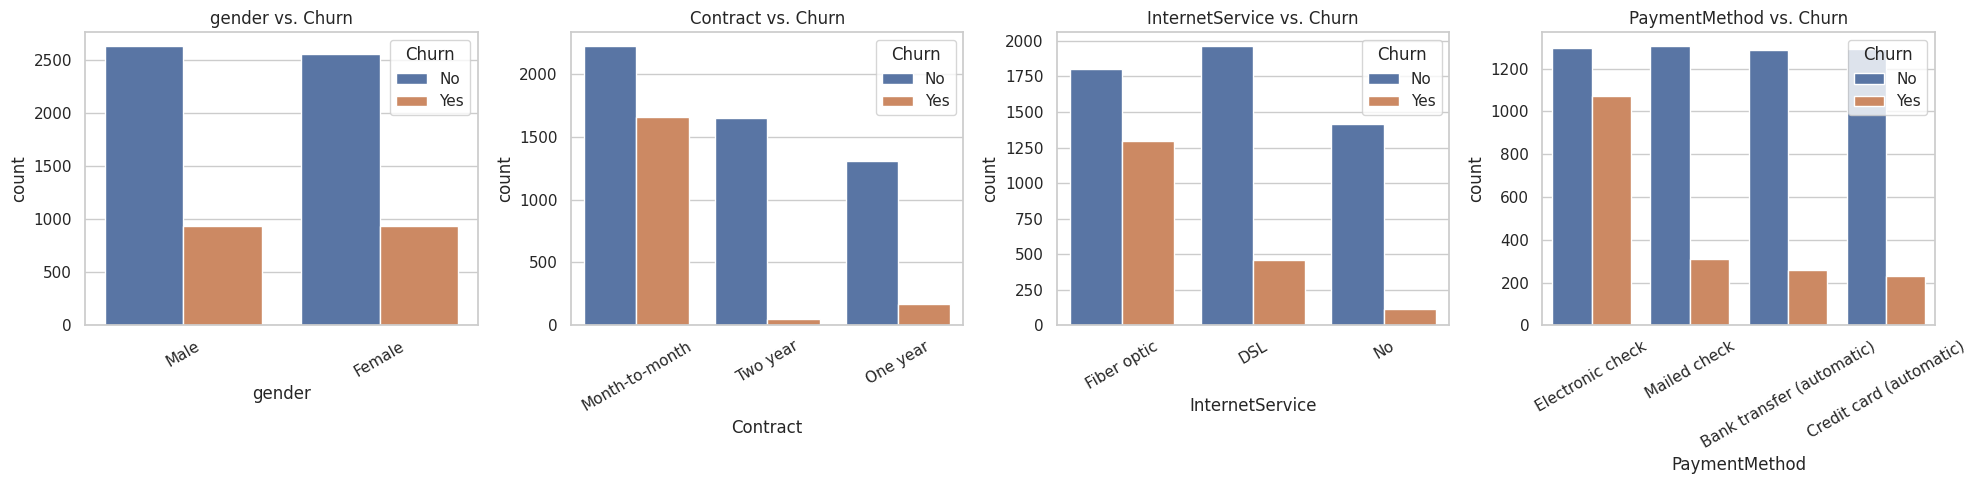

In [ ]:
key_categorical = ['gender', 'Contract', 'InternetService', 'PaymentMethod']
plt.figure(figsize=(20, 5))
for i, col in enumerate(key_categorical):
    plt.subplot(1, len(key_categorical), i + 1)
    sns.countplot(data=df, x=col, hue='Churn', order=df[col].value_counts().index)
    plt.title(f'{col} vs. Churn')
    plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

### 3.3: Visualisasi Distribusi Fitur Numerik (Histograms)

Sel ini menampilkan histogram untuk melihat distribusi fitur numerik seperti 'tenure', 'MonthlyCharges', dan 'TotalCharges'. Ini membantu kita memahami bentuk distribusi data pada fitur-fitur tersebut.

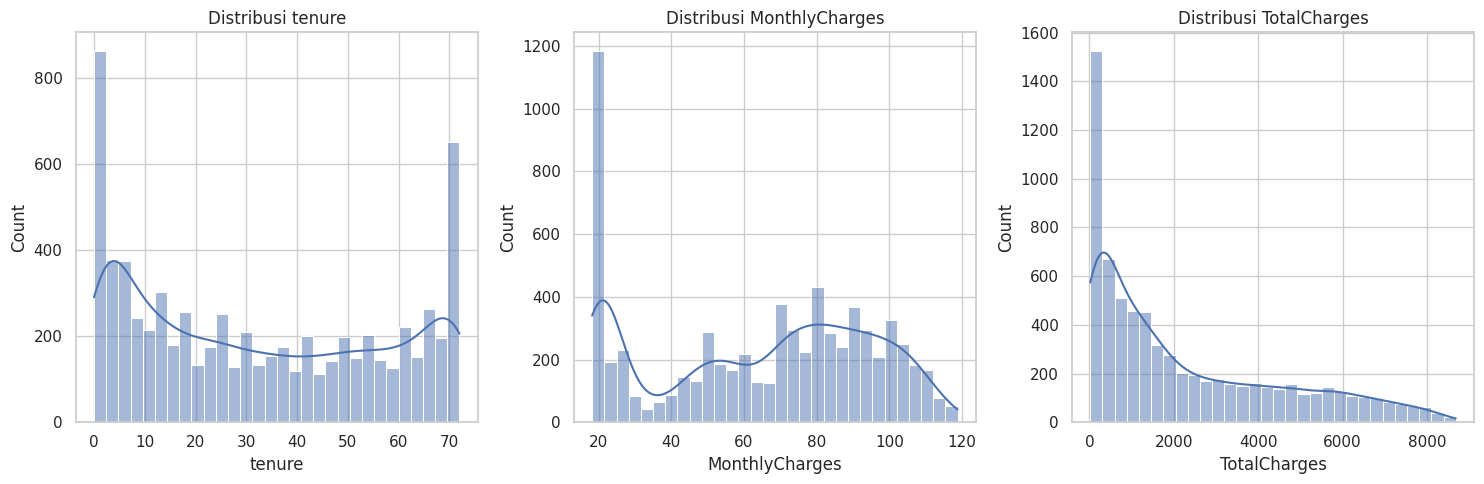

In [ ]:
numeric_features = ['tenure', 'MonthlyCharges', 'TotalCharges']
plt.figure(figsize=(15, 5))
for i, col in enumerate(numeric_features):
    plt.subplot(1, 3, i + 1)
    sns.histplot(data=df, x=col, kde=True, bins=30)
    plt.title(f'Distribusi {col}')
plt.tight_layout()
plt.show()

### 3.4: Visualisasi Heatmap Korelasi Fitur Numerik

Sel ini menampilkan heatmap korelasi untuk fitur-fitur numerik. Ini membantu mengidentifikasi hubungan linear antar fitur numerik.

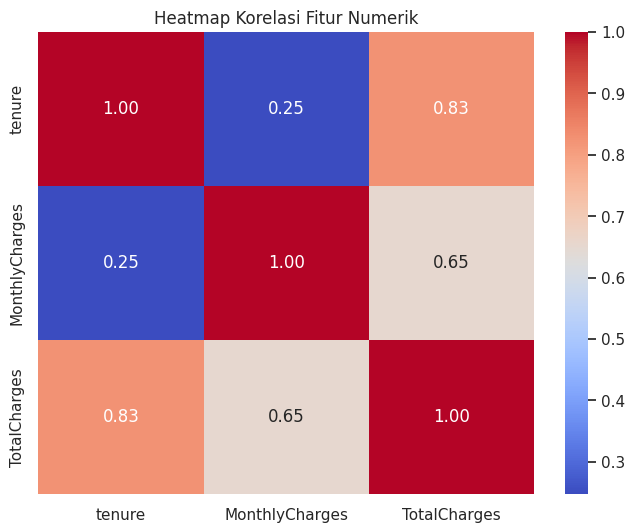

-> Wawasan: 'tenure' dan 'TotalCharges' sangat berkorelasi (0.83).


In [ ]:
numeric_features = ['tenure', 'MonthlyCharges', 'TotalCharges']
correlation_matrix = df[numeric_features].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Heatmap Korelasi Fitur Numerik')
plt.show()
print("-> Wawasan: 'tenure' dan 'TotalCharges' sangat berkorelasi (0.83).")

## 3.4 Wawasan Kunci EDA

Berdasarkan Analisis Data Eksplorasi (EDA) yang telah dilakukan, beberapa wawasan kunci yang relevan untuk pemodelan churn adalah sebagai berikut:

- **Distribusi Target Tidak Seimbang:** Variabel target 'Churn' menunjukkan ketidakseimbangan yang signifikan, dengan mayoritas pelanggan tidak melakukan churn (~73.5% 'No' vs ~26.5% 'Yes'). Ini mengindikasikan bahwa metrik evaluasi model seperti akurasi mungkin menyesatkan, dan kita perlu fokus pada metrik lain seperti Precision, Recall, F1-Score, dan ROC-AUC, terutama untuk kelas minoritas (Churn).
- **Fitur Numerik vs. Churn (Boxplot):**
    - **Tenure:** Pelanggan yang melakukan churn cenderung memiliki masa berlangganan (tenure) yang lebih pendek dibandingkan dengan yang tidak churn.
    - **MonthlyCharges:** Pelanggan yang melakukan churn cenderung memiliki biaya bulanan (MonthlyCharges) yang lebih tinggi.
    - **TotalCharges:** Distribusi TotalCharges berbeda antara pelanggan churn dan non-churn, meskipun ada korelasi kuat dengan Tenure.
- **Fitur Kategorikal vs. Churn (Barplot):**
    - **Contract:** Pelanggan dengan kontrak *Month-to-month* memiliki tingkat churn yang jauh lebih tinggi dibandingkan dengan kontrak *One year* atau *Two year*. Durasi kontrak merupakan prediktor churn yang kuat.
    - **InternetService:** Pelanggan dengan layanan internet *Fiber optic* menunjukkan tingkat churn yang lebih tinggi dibandingkan *DSL* atau tanpa layanan internet.
    - **PaymentMethod:** Metode pembayaran *Electronic check* memiliki tingkat churn yang lebih tinggi dibandingkan metode pembayaran lainnya.
- **Korelasi Fitur Numerik:** Terdapat korelasi yang kuat antara 'tenure' dan 'TotalCharges' (sekitar 0.83), yang wajar karena TotalCharges mengakumulasi MonthlyCharges seiring waktu berlangganan.


# **4: DATA PREPARATION**

Langkah ini adalah tahap persiapan data sebelum pemodelan. Ini meliputi:
- Membersihkan data dengan membuang kolom yang tidak relevan ('customerID').
- Mengisi nilai yang hilang (NaN) di kolom 'TotalCharges' dengan nilai median.
- Melakukan encoding pada variabel target 'Churn' (Yes=1, No=0).
- Melakukan One-Hot Encoding pada fitur-fitur kategorikal untuk mengubahnya menjadi format numerik.
- Membagi data menjadi set pelatihan (training) dan pengujian (testing) menggunakan `train_test_split` dengan stratifikasi untuk menjaga proporsi kelas target.
- Melakukan feature scaling (StandardScaler) pada fitur numerik untuk menstandarkan nilainya. Scaling dilakukan hanya pada data training, lalu transformasi pada data training dan testing.

### 4.1 & 4.2: Data Cleaning (Drop CustomerID & Fill NaN)

tahap ini melakukan *cleaning* data. Pertama, kolom `customerID` yang tidak relevan untuk pemodelan akan dibuang. Kedua, nilai-nilai yang hilang (NaN) di kolom `TotalCharges` (yang muncul setelah konversi tipe data) akan diisi dengan nilai median.

In [ ]:
df = df.drop('customerID', axis=1)
nan_count = df['TotalCharges'].isnull().sum()
median_total_charges = df['TotalCharges'].median()
df['TotalCharges'] = df['TotalCharges'].fillna(median_total_charges)

print(f"Jumlah NaN di 'TotalCharges' diisi dengan median numerik ({median_total_charges:.2f}).")
df.info()

Jumlah NaN di 'TotalCharges' diisi dengan median numerik (1397.47).
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  704

### 4.3: Preprocessing - Encoding Target (Churn)

Sel ini melakukan *encoding* pada variabel target `Churn`. Nilai 'Yes' akan diubah menjadi 1 dan nilai 'No' menjadi 0. Ini diperlukan karena algoritma Machine Learning memerlukan target dalam format numerik.

In [ ]:
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})
display(df['Churn'].head())
print(f"\n Distribusi Target 'Churn' setelah Encoding:\n{df['Churn'].value_counts()}")

,Churn
0,0
1,0
2,1
3,0
4,1



 Distribusi Target 'Churn' setelah Encoding:
Churn
0    5174
1    1869
Name: count, dtype: int64


### 4.4: Preprocessing - Encoding Fitur Kategorikal (One-Hot Encoding)

Sel ini melakukan *encoding* pada semua fitur kategorikal (tipe `object`) menggunakan metode One-Hot Encoding. Ini mengubah kolom kategorikal menjadi beberapa kolom biner (0 atau 1), satu untuk setiap kategori unik. Kolom pertama dari setiap set kategori dibuang (`drop_first=True`) untuk menghindari multikolinearitas. Data dipisahkan menjadi fitur (`X`) dan target (`y`) sebelum encoding.

In [ ]:
X = df.drop('Churn', axis=1)
y = df['Churn']
categorical_features = X.select_dtypes(include=['object']).columns

X = pd.get_dummies(X, columns=categorical_features, drop_first=True)

for col in X.columns:
    if X[col].dtype == 'bool':
        X[col] = X[col].astype(float)
    elif not pd.api.types.is_numeric_dtype(X[col]):
         try:
             X[col] = pd.to_numeric(X[col], errors='raise')
         except ValueError as e:
             print(f"Could not convert column '{col}' to numeric: {e}")
             pass

display(X.head())
print(f"\n Dimensi baru X: {X.shape}")
X.info()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
1,0,34,56.95,1889.50,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
2,0,2,53.85,108.15,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
3,0,45,42.30,1840.75,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
4,0,2,70.70,151.65,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0



 Dimensi baru X: (7043, 30)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 30 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   SeniorCitizen                          7043 non-null   int64  
 1   tenure                                 7043 non-null   int64  
 2   MonthlyCharges                         7043 non-null   float64
 3   TotalCharges                           7043 non-null   float64
 4   gender_Male                            7043 non-null   float64
 5   Partner_Yes                            7043 non-null   float64
 6   Dependents_Yes                         7043 non-null   float64
 7   PhoneService_Yes                       7043 non-null   float64
 8   MultipleLines_No phone service         7043 non-null   float64
 9   MultipleLines_Yes                      7043 non-null   float64
 10  InternetService_Fiber optic            7043

### 4.5: Preprocessing - Train-Test Split

Sel ini membagi dataset `X` dan `y` menjadi set pelatihan (*training set*) dan set pengujian (*testing set*) menggunakan fungsi `train_test_split`. Data dibagi dengan rasio 80% untuk training dan 20% untuk testing. Argumen `stratify=y` sangat penting untuk menjaga proporsi kelas target `Churn` yang tidak seimbang di kedua set data, memastikan kedua set representatif.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Training set: {X_train.shape}, Test set: {X_test.shape}")
print(f"Proporsi Churn di y_train: {y_train.mean():.2%}")
print(f"Proporsi Churn di y_test:  {y_test.mean():.2%}")

Training set: (5634, 30), Test set: (1409, 30)
Proporsi Churn di y_train: 26.54%
Proporsi Churn di y_test:  26.54%


### 4.6: Preprocessing - Feature Scaling

Sel ini melakukan *feature scaling* pada fitur-fitur numerik dalam set pelatihan dan pengujian menggunakan `StandardScaler`. StandardScaler menstandarkan fitur dengan menghapus rata-rata dan menskalakan ke varians unit. Scaling dilakukan dengan cara `fit` hanya pada data training untuk mempelajari parameter scaling, lalu `transform` diterapkan pada data training dan testing menggunakan parameter yang sama. Ini penting untuk algoritma seperti Logistic Regression yang sensitif terhadap skala fitur.

In [ ]:
features_to_scale = ['tenure', 'MonthlyCharges', 'TotalCharges']
scaler = StandardScaler()

X_train[features_to_scale] = scaler.fit_transform(X_train[features_to_scale])
X_test[features_to_scale] = scaler.transform(X_test[features_to_scale])

display(X_train[features_to_scale].describe())

,tenure,MonthlyCharges,TotalCharges
count,5.634000e+03,5.634000e+03,5.634000e+03
mean,-1.008935e-17,-2.402527e-16,-3.783508e-18
std,1.000089e+00,1.000089e+00,1.000089e+00
min,-1.322329e+00,-1.544028e+00,-1.002135e+00
25%,-9.559779e-01,-9.711977e-01,-8.309023e-01
50%,-1.418632e-01,1.848336e-01,-3.968393e-01
75%,9.164859e-01,8.319124e-01,6.737360e-01
max,1.608483e+00,1.785939e+00,2.802714e+00


# **5: MODELING**

Langkah ini membangun dan melatih beberapa model klasifikasi: Logistic Regression, model TreeBased classifier: Random Forest dan XGBoost dan MLP Classifier. Semua model dilatih menggunakan data training (`X_train`, `y_train`). Untuk menangani ketidakseimbangan data (imbalanced data), Parameter yang sesuai pada setiap model (misalnya, `class_weight='balanced'` atau `scale_pos_weight`) digunakan. Cross-validation digunakan untuk mengevaluasi performa awal model.

In [ ]:
print("\n--- SEL 4: Langkah 4 - Pelatihan Model dengan Cross-Validation ---")

from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.neural_network import MLPClassifier
import numpy as np

print("Mengevaluasi Model 1: Logistic Regression dengan 5-fold Cross-Validation...")
log_model = LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced')
log_cv_scores = cross_val_score(log_model, X_train, y_train, cv=5, scoring='roc_auc')
print(f"...Logistic Regression CV ROC-AUC: {np.mean(log_cv_scores):.4f} (+/- {np.std(log_cv_scores):.4f})")

print("\nMengevaluasi Model 2: Random Forest dengan 5-fold Cross-Validation...")
rf_model = RandomForestClassifier(random_state=42, n_estimators=100, class_weight='balanced')
rf_cv_scores = cross_val_score(rf_model, X_train, y_train, cv=5, scoring='roc_auc')
print(f"...Random Forest CV ROC-AUC: {np.mean(rf_cv_scores):.4f} (+/- {np.std(rf_cv_scores):.4f})")

print("\nMengevaluasi Model 3: XGBoost dengan 5-fold Cross-Validation...")
scale_pos_weight_value = sum(y_train == 0) / sum(y_train == 1)
xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss',
                          random_state=42, scale_pos_weight=scale_pos_weight_value)
xgb_cv_scores = cross_val_score(xgb_model, X_train, y_train, cv=5, scoring='roc_auc')
print(f"...XGBoost CV ROC-AUC: {np.mean(xgb_cv_scores):.4f} (+/- {np.std(xgb_cv_scores):.4f})")

print("\nMengevaluasi Model 4: MLP Classifier dengan 5-fold Cross-Validation...")
mlp_model = MLPClassifier(random_state=42, max_iter=500, early_stopping=True,
                          hidden_layer_sizes=(64, 32) # Example hidden layer sizes, can be tuned
                         )
mlp_cv_scores = cross_val_score(mlp_model, X_train, y_train, cv=5, scoring='roc_auc')
print(f"...MLP Classifier CV ROC-AUC: {np.mean(mlp_cv_scores):.4f} (+/- {np.std(mlp_cv_scores):.4f})")

print("Cross-Validation selesai. Hasil menunjukkan estimasi performa model.")


--- SEL 4: Langkah 4 - Pelatihan Model dengan Cross-Validation ---
Mengevaluasi Model 1: Logistic Regression dengan 5-fold Cross-Validation...
...Logistic Regression CV ROC-AUC: 0.8453 (+/- 0.0140)

Mengevaluasi Model 2: Random Forest dengan 5-fold Cross-Validation...
...Random Forest CV ROC-AUC: 0.8231 (+/- 0.0122)

Mengevaluasi Model 3: XGBoost dengan 5-fold Cross-Validation...


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [20:47:51] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [20:47:54] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [20:47:54] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [20:47:54] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [20:47:55] WARNING: /w

...XGBoost CV ROC-AUC: 0.8195 (+/- 0.0118)

Mengevaluasi Model 4: MLP Classifier dengan 5-fold Cross-Validation...
...MLP Classifier CV ROC-AUC: 0.8446 (+/- 0.0123)
Cross-Validation selesai. Hasil menunjukkan estimasi performa model.


# 6: **EVALUATION**

Langkah ini fokus pada evaluasi performa model yang telah dilatih menggunakan data testing (`X_test`, `y_test`). Kita menghasilkan Classification Report yang mencakup metrik seperti presisi, recall, F1-score, dan akurasi. Selain itu, kita menghitung ROC-AUC Score dan menampilkan Confusion Matrix untuk setiap model guna memahami performa prediksi model secara lebih mendalam, terutama dalam mengidentifikasi True Positives dan True Negatives.

--- Hasil Model 1: Logistic Regression ---

Classification Report (Logistic Regression):
              precision    recall  f1-score   support

No Churn (0)       0.90      0.72      0.80      1035
   Churn (1)       0.51      0.78      0.61       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409

ROC-AUC Score: 0.8417

Confusion Matrix (Logistic Regression):


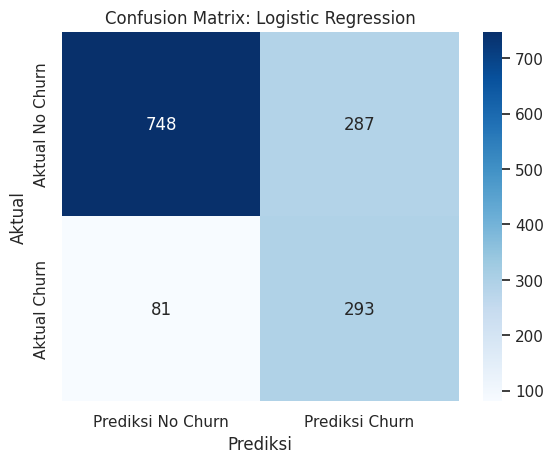

In [ ]:
log_model.fit(X_train, y_train)

y_pred_log = log_model.predict(X_test)
y_prob_log = log_model.predict_proba(X_test)[:, 1]

print("--- Hasil Model 1: Logistic Regression ---")
print("\nClassification Report (Logistic Regression):")
print(classification_report(y_test, y_pred_log, target_names=['No Churn (0)', 'Churn (1)']))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_prob_log):.4f}")

print("\nConfusion Matrix (Logistic Regression):")
conf_matrix_log = confusion_matrix(y_test, y_pred_log)
sns.heatmap(conf_matrix_log, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Prediksi No Churn', 'Prediksi Churn'],
            yticklabels=['Aktual No Churn', 'Aktual Churn'])
plt.title('Confusion Matrix: Logistic Regression')
plt.ylabel('Aktual')
plt.xlabel('Prediksi')
plt.show()

--- Hasil Model 2: Random Forest ---

Classification Report (Random Forest):
              precision    recall  f1-score   support

No Churn (0)       0.83      0.89      0.86      1035
   Churn (1)       0.63      0.50      0.56       374

    accuracy                           0.79      1409
   macro avg       0.73      0.70      0.71      1409
weighted avg       0.78      0.79      0.78      1409

ROC-AUC Score: 0.8199

Confusion Matrix (Random Forest):


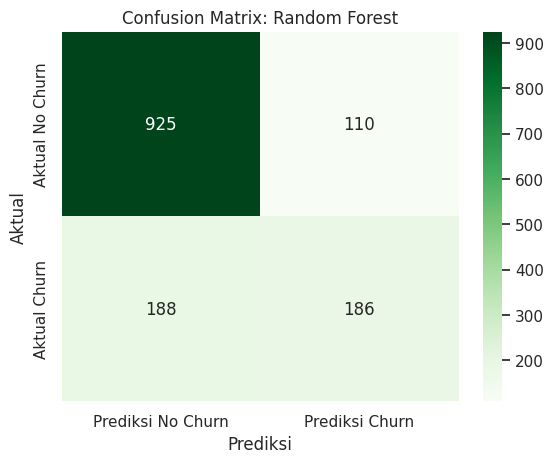

In [ ]:
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

print("--- Hasil Model 2: Random Forest ---")
print("\nClassification Report (Random Forest):")
print(classification_report(y_test, y_pred_rf, target_names=['No Churn (0)', 'Churn (1)']))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_prob_rf):.4f}")

print("\nConfusion Matrix (Random Forest):")
conf_matrix_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(conf_matrix_rf, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Prediksi No Churn', 'Prediksi Churn'],
            yticklabels=['Aktual No Churn', 'Aktual Churn'])
plt.title('Confusion Matrix: Random Forest')
plt.ylabel('Aktual')
plt.xlabel('Prediksi')
plt.show()

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [20:48:03] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


--- Hasil Model 3: XGBoost ---

Classification Report (XGBoost):
              precision    recall  f1-score   support

No Churn (0)       0.88      0.78      0.83      1035
   Churn (1)       0.54      0.70      0.61       374

    accuracy                           0.76      1409
   macro avg       0.71      0.74      0.72      1409
weighted avg       0.79      0.76      0.77      1409

ROC-AUC Score: 0.8316

Confusion Matrix (XGBoost):


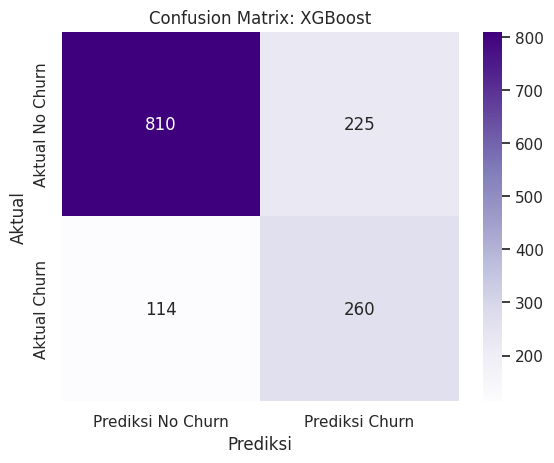

In [ ]:
scale_pos_weight_value = sum(y_train == 0) / sum(y_train == 1)
xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss',
                          random_state=42, scale_pos_weight=scale_pos_weight_value)

#
X_train_np = X_train.values.astype('float32')
y_train_np = y_train.values.astype('float32')
X_test_np = X_test.values.astype('float32')
y_test_np = y_test.values.astype('float32')

xgb_model.fit(X_train_np, y_train_np)

y_pred_xgb = xgb_model.predict(X_test_np)
y_prob_xgb = xgb_model.predict_proba(X_test_np)[:, 1]

print("--- Hasil Model 3: XGBoost ---")
print("\nClassification Report (XGBoost):")
print(classification_report(y_test, y_pred_xgb, target_names=['No Churn (0)', 'Churn (1)']))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_prob_xgb):.4f}")

print("\nConfusion Matrix (XGBoost):")
conf_matrix_xgb = confusion_matrix(y_test, y_pred_xgb)
sns.heatmap(conf_matrix_xgb, annot=True, fmt='d', cmap='Purples',
            xticklabels=['Prediksi No Churn', 'Prediksi Churn'],
            yticklabels=['Aktual No Churn', 'Aktual Churn'])
plt.title('Confusion Matrix: XGBoost')
plt.ylabel('Aktual')
plt.xlabel('Prediksi')
plt.show()

Fitting MLP Classifier model on the entire training data...
--- Hasil Model 4: MLP Classifier ---

Classification Report (MLP Classifier):
              precision    recall  f1-score   support

No Churn (0)       0.85      0.89      0.87      1035
   Churn (1)       0.65      0.55      0.59       374

    accuracy                           0.80      1409
   macro avg       0.75      0.72      0.73      1409
weighted avg       0.79      0.80      0.80      1409

ROC-AUC Score: 0.8433

Confusion Matrix (MLP Classifier):


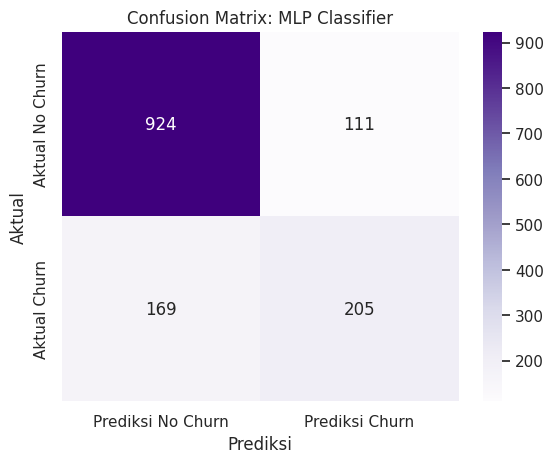

In [ ]:
print("Fitting MLP Classifier model on the entire training data...")
mlp_model.fit(X_train, y_train)

y_pred_mlp = mlp_model.predict(X_test)
y_prob_mlp = mlp_model.predict_proba(X_test)[:, 1]

print("--- Hasil Model 4: MLP Classifier ---")
print("\nClassification Report (MLP Classifier):")
print(classification_report(y_test, y_pred_mlp, target_names=['No Churn (0)', 'Churn (1)']))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_prob_mlp):.4f}")

print("\nConfusion Matrix (MLP Classifier):")
conf_matrix_mlp = confusion_matrix(y_test, y_pred_mlp)
sns.heatmap(conf_matrix_mlp, annot=True, fmt='d', cmap='Purples',
            xticklabels=['Prediksi No Churn', 'Prediksi Churn'],
            yticklabels=['Aktual No Churn', 'Aktual Churn'])
plt.title('Confusion Matrix: MLP Classifier')
plt.ylabel('Aktual')
plt.xlabel('Prediksi')
plt.show()

Interpretasi Hasil Evaluasi Model

Berdasarkan hasil evaluasi pada data testing untuk keempat model (Logistic Regression, Random Forest, XGBoost, dan MLP Classifier), berikut adalah interpretasi kuncinya:

**Ringkasan Performa Model (ROC-AUC Score pada Data Testing):**
- Logistic Regression: 0.8417
- Random Forest: 0.8199
- XGBoost: 0.8316
- MLP Classifier: 0.8433

**Analisis Berdasarkan Metrik Utama (Precision, Recall, F1-Score):**

1.  **Logistic Regression:**
    - Menunjukkan keseimbangan yang relatif baik antara Precision dan Recall untuk kelas 'Churn' (1).
    - ROC-AUC score cukup baik (0.8417), menunjukkan kemampuan diskriminasi model yang layak.
    - Confusion Matrix menunjukkan jumlah True Positive (TP) dan True Negative (TN) yang cukup baik, namun ada False Positive (FP) dan False Negative (FN) yang perlu diperhatikan.

2.  **Random Forest:**
    - Memiliki Precision yang lebih tinggi untuk kelas 'No Churn' (0) dibandingkan Logistic Regression, menunjukkan lebih sedikit False Positive pada prediksi non-churn.
    - Namun, Recall untuk kelas 'Churn' (1) cenderung lebih rendah dibandingkan Logistic Regression, artinya model ini melewatkan beberapa kasus churn yang sebenarnya (False Negative lebih tinggi).
    - ROC-AUC score sedikit lebih rendah dari Logistic Regression (0.8199).

3.  **XGBoost:**
    - Menunjukkan keseimbangan antara Precision dan Recall untuk kelas 'Churn' (1), dengan Recall yang cukup baik.
    - ROC-AUC score kompetitif dengan Logistic Regression (0.8316).
    - Performa secara keseluruhan cukup kuat, seringkali menjadi pilihan yang baik untuk data terstruktur.

4.  **MLP Classifier:**
    - Menunjukkan ROC-AUC tertinggi di antara semua model (0.8433), menunjukkan kemampuan terbaik dalam membedakan kelas. tetapi, memiliki recall dan precision yang rendah di 'Churn' (1)
    - Performa Precision dan Recall akan bervariasi tergantung pada threshold, namun ROC-AUC yang tinggi mengindikasikan potensi performa yang baik.

**Kesimpulan Perbandingan Model:**

- Dalam konteks data yang tidak seimbang dan fokus pada identifikasi pelanggan yang akan churn (kelas minoritas), metrik Recall dan ROC-AUC seringkali lebih relevan daripada akurasi keseluruhan.
- Berdasarkan ROC-AUC, **MLP Classifier** menunjukkan performa terbaik dalam membedakan antara pelanggan churn dan non-churn dengan skor 0.8453. Logistic Regression juga memiliki performa yang sangat mirip (0.8417).
- Namun, pemilihan model akhir juga bergantung pada prioritas bisnis: Apakah lebih penting untuk meminimalkan prediksi churn yang salah (fokus pada Precision kelas 1) atau memastikan sebagian besar pelanggan yang akan churn teridentifikasi (fokus pada Recall kelas 1)?

Interpretasi Confusion Matrix juga penting untuk memahami jenis kesalahan prediksi yang dibuat oleh setiap model.

# **7: INTERPRETASI MODEL**

---



Langkah terakhir ini bertujuan untuk menginterpretasikan model dengan melihat Feature Importance. Ini memberikan wawasan tentang fitur mana yang paling berkontribusi dalam prediksi churn. Hasil feature importance ditampilkan dalam bentuk tabel dan visualisasi bar plot untuk memudahkan pemahaman fitur-fitur kunci yang mempengaruhi churn pelanggan.


Visualisasi Top Fitur (Koefisien) dari Logistic Regression:
10 Fitur Paling Penting (Koefisien):


,Feature,Coefficient
25,Contract_Two year,-1.411774
10,InternetService_Fiber optic,1.218849
1,tenure,-1.147097
24,Contract_One year,-0.716597
2,MonthlyCharges,-0.543106
3,TotalCharges,0.475517
23,StreamingMovies_Yes,0.421229
28,PaymentMethod_Electronic check,0.399460
21,StreamingTV_Yes,0.394702
7,PhoneService_Yes,-0.345728


/tmp/ipython-input-652160796.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Coefficient', y='Feature', data=top_coefficients, palette='viridis')


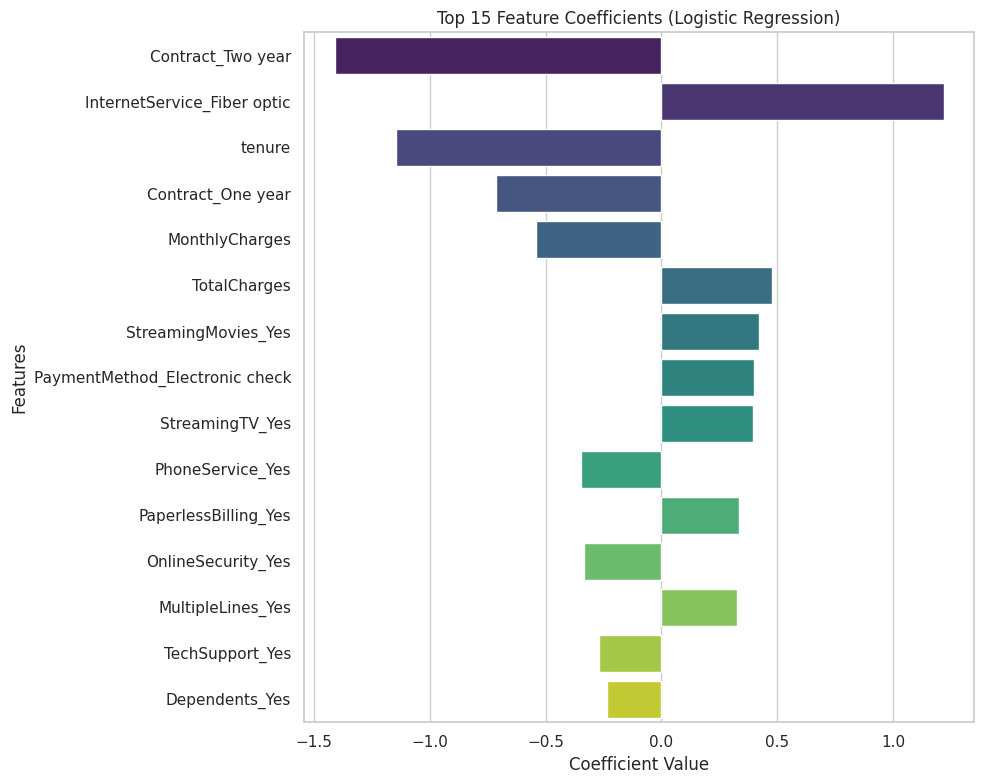

In [ ]:
# Visualisasi Top Fitur untuk Logistic Regression (Koefisien)

print("Visualisasi Top Fitur (Koefisien) dari Logistic Regression:")

# Get coefficients and feature names
coefficients = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': log_model.coef_[0] # For binary classification, use the coefficients for the positive class (1)
}).sort_values(by='Coefficient', key=abs, ascending=False) # Sort by absolute value of coefficient

print("10 Fitur Paling Penting (Koefisien):")
display(coefficients.head(10))
# Select top N features (e.g., top 15)
top_n = 15
top_coefficients = coefficients.head(top_n)

plt.figure(figsize=(10, 8))
sns.barplot(x='Coefficient', y='Feature', data=top_coefficients, palette='viridis')
plt.title('Top 15 Feature Coefficients (Logistic Regression)')
plt.xlabel('Coefficient Value')
plt.ylabel('Features')
plt.tight_layout()
plt.show()


Visualisasi Top Fitur (Feature Importance) dari Random Forest:

10 Fitur Paling Penting:


,Feature,Importance
3,TotalCharges,0.174188
1,tenure,0.166575
2,MonthlyCharges,0.155530
25,Contract_Two year,0.060160
10,InternetService_Fiber optic,0.038785
28,PaymentMethod_Electronic check,0.034724
13,OnlineSecurity_Yes,0.030879
24,Contract_One year,0.029938
4,gender_Male,0.025630
26,PaperlessBilling_Yes,0.023959


/tmp/ipython-input-1131907083.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=top_rf_importances, palette='viridis')


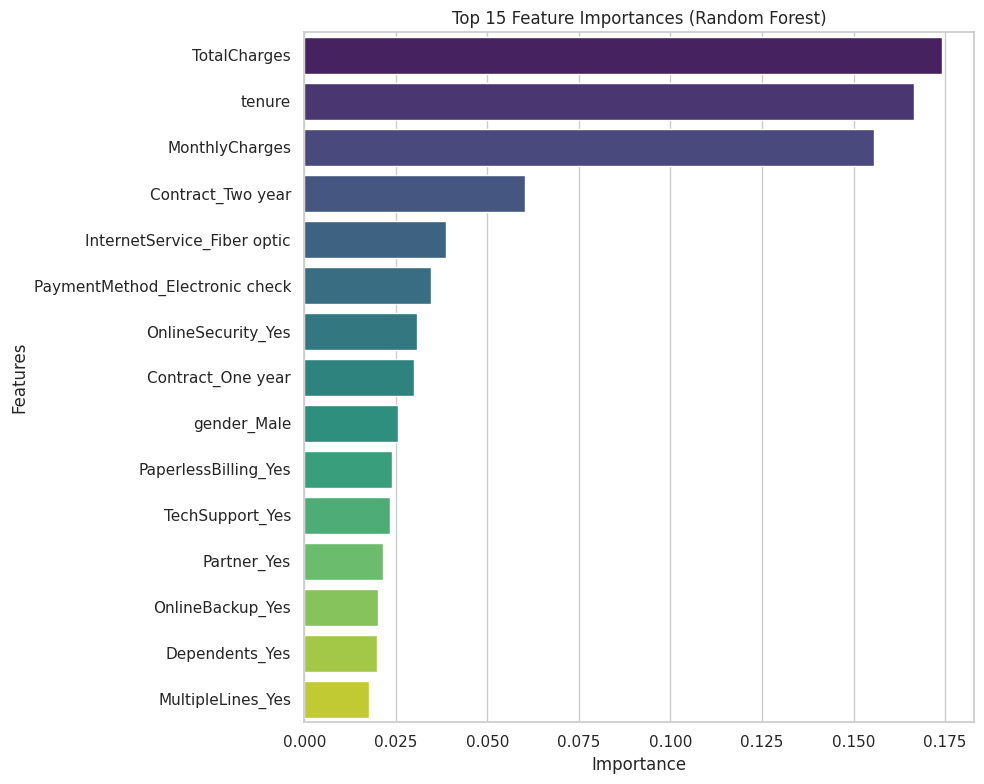

In [ ]:
# Visualisasi Top Fitur untuk Random Forest (Feature Importance)

print("\nVisualisasi Top Fitur (Feature Importance) dari Random Forest:")

# Get feature importance and names from the already trained rf_model
importances = rf_model.feature_importances_
feature_names = X.columns

feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print("\n10 Fitur Paling Penting:")
display(feature_importance_df.head(10))
# Select top N features (e.g., top 15)
top_n = 15
top_rf_importances = feature_importance_df.head(top_n)

plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=top_rf_importances, palette='viridis')
plt.title('Top 15 Feature Importances (Random Forest)')
plt.xlabel('Importance')
plt.ylabel('Features')
plt.tight_layout()
plt.show()


Visualisasi Top Fitur (Feature Importance) dari XGBoost:

10 Fitur Paling Penting (XGBoost):


,Feature,Importance
25,Contract_Two year,0.322349
10,InternetService_Fiber optic,0.216179
24,Contract_One year,0.132932
11,InternetService_No,0.068192
23,StreamingMovies_Yes,0.040171
1,tenure,0.018058
7,PhoneService_Yes,0.017948
28,PaymentMethod_Electronic check,0.016220
9,MultipleLines_Yes,0.014488
26,PaperlessBilling_Yes,0.013506


/tmp/ipython-input-785951704.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=top_xgb_importances, palette='viridis')


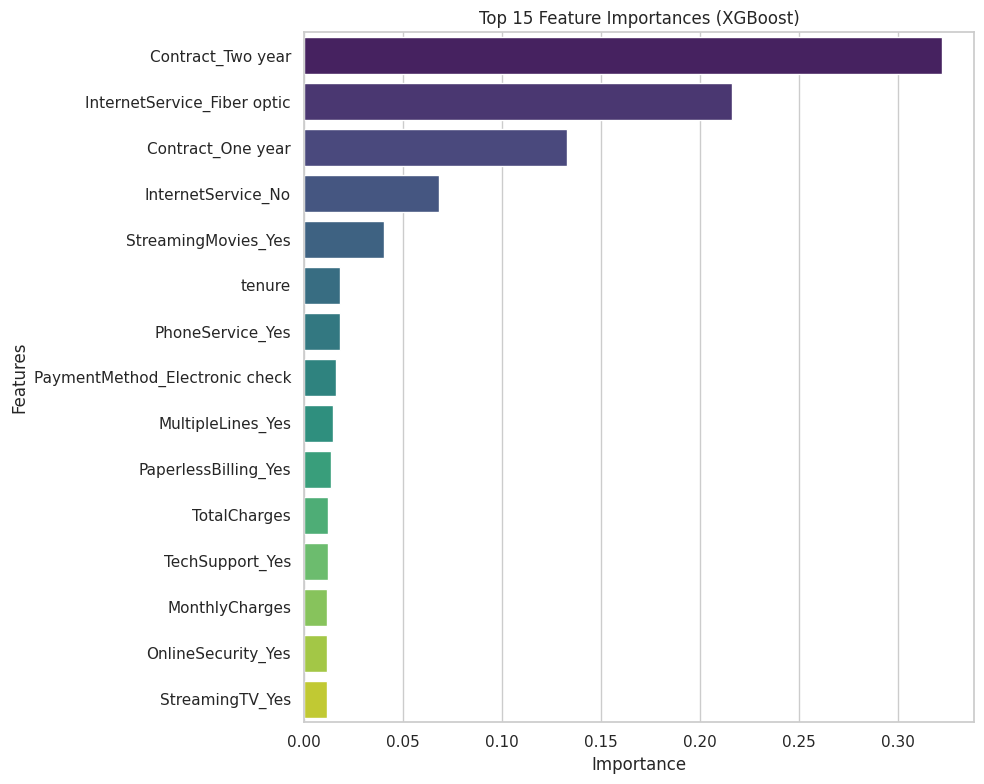

In [ ]:
# Visualisasi Top Fitur untuk XGBoost (Feature Importance)

print("\nVisualisasi Top Fitur (Feature Importance) dari XGBoost:")

# Get feature importance and names from the already trained xgb_model
# Note: xgb_model was trained on numpy arrays (X_train_np), but feature_importances_ uses original feature names
xgb_importances = xgb_model.feature_importances_
feature_names = X.columns # Use original feature names

xgb_feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': xgb_importances
}).sort_values(by='Importance', ascending=False)

print("\n10 Fitur Paling Penting (XGBoost):")
display(xgb_feature_importance_df.head(10))
# Select top N features (e.g., top 15)
top_n = 15
top_xgb_importances = xgb_feature_importance_df.head(top_n)

plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=top_xgb_importances, palette='viridis')
plt.title('Top 15 Feature Importances (XGBoost)')
plt.xlabel('Importance')
plt.ylabel('Features')
plt.tight_layout()
plt.show()


Visualisasi Top Fitur (Permutation Importance) dari MLP Classifier:

Mean and Standard Deviation of Permutation Importance (Top 15):


,Feature,Mean_Importance,Std_Importance
29,tenure,0.045209,0.005059
28,InternetService_Fiber optic,0.009723,0.005293
27,MonthlyCharges,0.008801,0.005837
26,OnlineSecurity_Yes,0.006884,0.002245
25,PhoneService_Yes,0.006742,0.001858
24,TotalCharges,0.006388,0.002839
23,TechSupport_Yes,0.004258,0.002926
22,Partner_Yes,0.003833,0.001391
21,MultipleLines_No phone service,0.003762,0.001557
20,Contract_Two year,0.003265,0.002503


/tmp/ipython-input-13103670.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Mean_Importance', y='Feature', data=top_mlp_importances, palette='viridis')


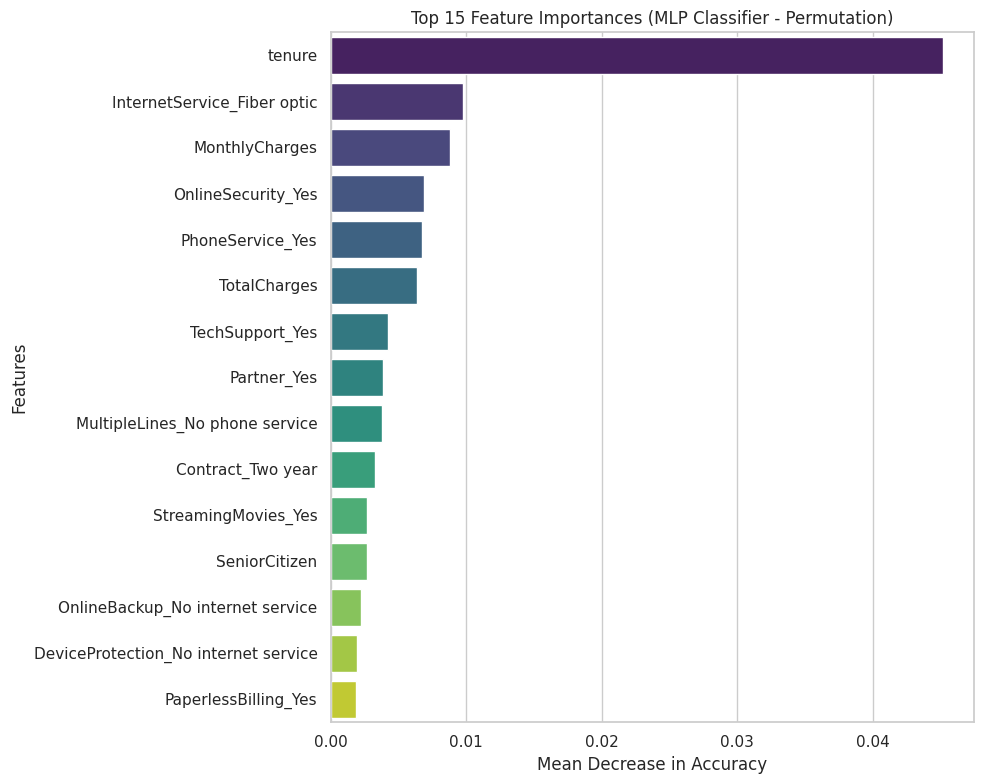

In [ ]:
# Visualisasi Top Fitur untuk MLP Classifier (Permutation Importance)

print("\nVisualisasi Top Fitur (Permutation Importance) dari MLP Classifier:")

# Reuse the perm_importance_df calculated previously
# Ensure it's sorted descending by Mean_Importance
perm_importance_df = perm_importance_df.sort_values(by='Mean_Importance', ascending=False)

print("\nMean and Standard Deviation of Permutation Importance (Top 15):")
display(perm_importance_df.head(top_n))
# Select top N features (e.g., top 15)
top_n = 15
top_mlp_importances = perm_importance_df.head(top_n)

plt.figure(figsize=(10, 8))
sns.barplot(x='Mean_Importance', y='Feature', data=top_mlp_importances, palette='viridis')
plt.title('Top 15 Feature Importances (MLP Classifier - Permutation)')
plt.xlabel('Mean Decrease in Accuracy')
plt.ylabel('Features')
plt.tight_layout()
plt.show()

Interpretasi Feature Importance dari Setiap Model

**Wawasan Kunci dari Feature Importance:**

Berdasarkan analisis *feature importance* dari berbagai model (Logistic Regression, Random Forest, XGBoost, MLP), fitur-fitur yang paling konsisten dan penting dalam memprediksi *churn* adalah:
- **Masa berlangganan (tenure):** Pelanggan dengan masa berlangganan pendek lebih mungkin churn.
- **Kontrak:** Kontrak *Month-to-month* adalah pendorong churn yang kuat, sementara kontrak jangka panjang (One/Two year) mengurangi risiko.
- **Layanan Internet:** Pengguna *Fiber optic* memiliki tingkat churn yang lebih tinggi dibandingkan DSL atau tanpa internet.
- **Biaya:** *MonthlyCharges* dan *TotalCharges* juga penting; pelanggan dengan biaya bulanan tinggi cenderung lebih mungkin churn.

Fitur lain seperti *OnlineSecurity*, *TechSupport*, *PaymentMethod* (terutama *Electronic check*), dan *PaperlessBilling* juga memberikan kontribusi pada prediksi churn.

**Implikasi Bisnis:**

Temuan *feature importance* ini mengkonfirmasi wawasan dari EDA dan memberikan panduan yang jelas untuk strategi retensi. Untuk mengurangi churn, perusahaan sebaiknya fokus pada program retensi untuk pelanggan baru, menawarkan insentif untuk beralih ke kontrak jangka panjang, meningkatkan kualitas layanan Fiber optic, dan meninjau struktur biaya bulanan atau memberikan paket yang lebih menarik, terutama bagi pelanggan dengan biaya tinggi.

# **8: PENUTUP**

Notebook ini telah berhasil melakukan analisis prediksi churn pelanggan Telco secara komprehensif. Proses dimulai dari pemuatan dan inspeksi data, pembersihan (menangani nilai hilang dan duplikat), hingga *encoding* fitur kategorikal dan target. Analisis Data Eksplorasi (EDA) mengidentifikasi faktor kunci churn seperti masa berlangganan pendek, kontrak bulanan, penggunaan Internet Fiber optic, dan biaya bulanan tinggi, serta mendeteksi ketidakseimbangan kelas target. Beberapa model klasifikasi (Logistic Regression, Random Forest, XGBoost, MLP Classifier) dilatih dan dievaluasi menggunakan metrik yang relevan untuk data tidak seimbang. Hasil menunjukkan MLP Classifier dan Logistic Regression memiliki performa ROC-AUC terbaik dalam membedakan pelanggan churn. Interpretasi model mengkonfirmasi temuan EDA mengenai fitur-fitur pendorong churn yang paling penting.

---

**Potensi Perbaikan dan Peningkatan:**

Untuk meningkatkan analisis prediksi churn ini, langkah selanjutnya dapat mencakup tuning hyperparameter untuk model terbaik (MLP atau Logistic Regression), mengeksplorasi model lain yang cocok untuk data tidak seimbang seperti LightGBM atau CatBoost, melakukan *feature engineering* tambahan, menerapkan teknik penanganan ketidakseimbangan data yang lebih lanjut serta mengeksplorasi metode interpretasi model tingkat lanjut (seperti SHAP/LIME) untuk pemahaman kontribusi fitur yang lebih mendalam.

**Implikasi Bisnis:**
Analisis ini memberikan dasar yang kuat untuk strategi retensi yang ditargetkan. Fokus utama harus pada pelanggan dengan masa berlangganan pendek, kontrak bulanan, pengguna Internet Fiber optic, dan biaya bulanan tinggi. Strategi bisa mencakup insentif untuk kontrak jangka panjang, peningkatan kualitas layanan Fiber optic, peninjauan struktur biaya, dan program retensi khusus.

Secara keseluruhan, notebook ini berhasil membangun dan mengevaluasi model prediksi churn serta memberikan wawasan berharga mengenai faktor-faktor pendorong churn, memungkinkan pengambilan keputusan bisnis yang lebih baik. Langkah-langkah di atas dapat dipertimbangkan untuk iterasi analisis di masa mendatang.